# 08 — Threshold Optimisation

This notebook evaluates decision thresholds on the validation set, quantifies false positives and false negatives, and selects an operating point that balances them. It also exports the full threshold curve and the final chosen threshold.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import joblib

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

from pathlib import Path
from src.config import SENS_MIN, C_FP_RANGE, C_FN_RANGE, THRESHOLDS
from src.thresholding import optimize_threshold_grid, compute_detailed_curve
from src.visualization import (
    plot_cost_vs_threshold,
    plot_sensitivity_vs_threshold,
    plot_alerts_vs_threshold
)

In [2]:
# Load data
y_prob = pd.read_pickle("../reports/tables/y_prob.pkl")
y_te = pd.read_csv("../data/processed/y_te.csv")["target"]

In [3]:
# Global optimization over C_FP / C_FN
candidates_df, best_global = optimize_threshold_grid(
    y_true=y_te,
    y_prob=y_prob,
    thresholds=THRESHOLDS,
    C_FP_range=C_FP_RANGE,
    C_FN_range=C_FN_RANGE,
    sens_min=SENS_MIN
)

candidates_df.to_csv("../reports/tables/threshold_candidates_by_cost.csv", index=True)
candidates_df.head(10)

,threshold,C_FP,C_FN,TP,FP,FN,TN,Cost,Mean_alerts,Sens,Spec,Precision,F1,Youden
0,0.470,1,1,454,220,70,135,290,0.766780,0.866412,0.380282,0.673591,0.757930,0.246694
1,0.001,1,2,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
2,0.001,1,3,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
3,0.001,1,4,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
4,0.001,1,5,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
5,0.001,1,6,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
6,0.001,1,7,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
7,0.001,1,8,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
8,0.001,1,9,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
9,0.001,1,10,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169


In [4]:
# Detailed curve for selected (C_FP, C_FN)
sel_C_FP = int(best_global["C_FP"])
sel_C_FN = int(best_global["C_FN"])

curve_df = compute_detailed_curve(
    y_true=y_te,
    y_prob=y_prob,
    thresholds=THRESHOLDS,
    C_FP=sel_C_FP,
    C_FN=sel_C_FN
)
curve_df.to_csv(f"../reports/tables/threshold_curve_CFP{sel_C_FP}_CFN{sel_C_FN}.csv", index=True)
curve_df

,threshold,C_FP,C_FN,TP,FP,FN,TN,Cost,Mean_alerts,Sens,Spec,Precision,F1,Youden
0,0.000,1,1,524,355,0,0,355,1.000000,1.000000,0.000000,0.596132,0.746971,0.000000
1,0.001,1,1,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
2,0.002,1,1,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
3,0.003,1,1,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
4,0.004,1,1,524,345,0,10,345,0.988623,1.000000,0.028169,0.602992,0.752333,0.028169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.996,1,1,5,3,519,352,522,0.009101,0.009542,0.991549,0.625000,0.018797,0.001091
997,0.997,1,1,5,3,519,352,522,0.009101,0.009542,0.991549,0.625000,0.018797,0.001091
998,0.998,1,1,5,3,519,352,522,0.009101,0.009542,0.991549,0.625000,0.018797,0.001091
999,0.999,1,1,5,3,519,352,522,0.009101,0.009542,0.991549,0.625000,0.018797,0.001091


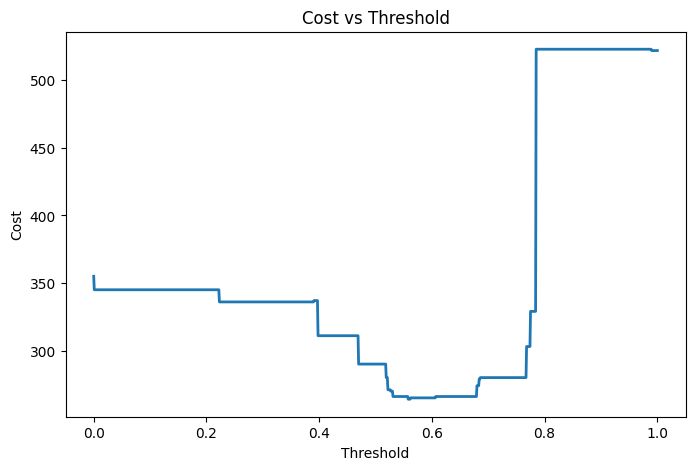

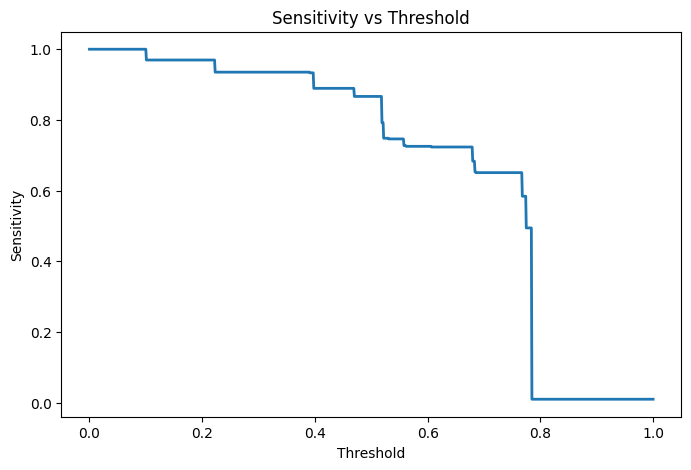

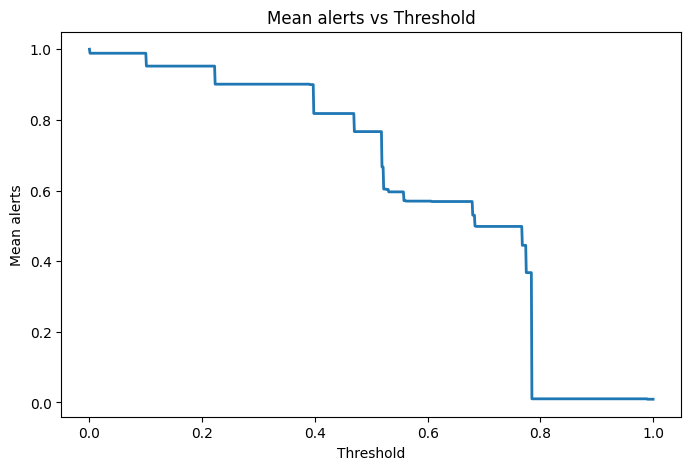

In [5]:
# Plots
fig_cost = plot_cost_vs_threshold(curve_df, "Cost vs Threshold")
fig_cost.savefig("../reports/figures/threshold_cost.png", dpi=300, bbox_inches="tight")

fig_sens = plot_sensitivity_vs_threshold(curve_df, "Sensitivity vs Threshold")
fig_sens.savefig("../reports/figures/threshold_sensitivity.png", dpi=300, bbox_inches="tight")

fig_alerts = plot_alerts_vs_threshold(curve_df, "Mean alerts vs Threshold")
fig_alerts.savefig("../reports/figures/threshold_alerts.png", dpi=300, bbox_inches="tight")

In [6]:
# Display best global choice
best_threshold = best_global.copy()
for col in ["TP", "FP", "FN", "TN", "C_FP", "C_FN"]:
    best_threshold[col] = int(best_threshold[col])
for col in ["threshold", "Sens", "Spec", "F1", "Youden", "Cost", "Mean_alerts"]:
    best_threshold[col] = round(float(best_threshold[col]), 3)

best_threshold.to_frame().T.to_csv("../reports/tables/best_threshold.csv", index=False)
display(best_threshold.to_frame().T)

,threshold,C_FP,C_FN,TP,FP,FN,TN,Cost,Mean_alerts,Sens,Spec,Precision,F1,Youden
0,0.47,1.0,1.0,454.0,220.0,70.0,135.0,290.0,0.767,0.866,0.38,0.673591,0.758,0.247
